# СБОРНЫЙ ПРОЕКТ: Выявление закономерностей успешных компьютерных игр и проверка гипотез для планирования продаж и маркетинга в интернет-магазине «Стримчик» 

<div style="border:solid green 2px; padding: 30px">
 <b> Цель проекта:</b>
        
Мы работаем в интернет-магазине «Стримчик», который продаёт по всему миру компьютерные игры. 
    
Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). 
    
 <b> ЗАДАЧА:</b>    
    
нужно выявить определяющие успешность игры закономерности. 
    
Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.
	
    
Перед нами данные до 2016 года. 
    
Представим, что сейчас декабрь 2016 г., и мы планируем кампанию на 2017-й. Нужно отработать принцип работы с данными. Неважно, прогнозируем ли мы продажи на 2017 год по данным 2016-го или же 2027-й — по данным 2026 года.

В наборе данных попадается аббревиатура ESRB (Entertainment Software Rating Board) — это ассоциация, определяющая возрастной рейтинг компьютерных игр. ESRB оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».

   
    

<b> План:</b>    
1) *Загрузить данные* : 
    
Путь к файлу: data/games.csv ;
    
    
2) *Провести предобработку данных*;
   
    
3) *Провести исследовательский анализ данных (EDA)* : 
    
- Посмотреть, сколько игр выпускалось в разные годы. (Важны ли данные за все периоды?)
    
- Посмотреть, как менялись продажи по платформам. Выбрать платформы с наибольшими суммарными продажами и построить распределение по годам. (За какой характерный срок появляются новые и исчезают старые платформы?)
    
Взять данные за соответствующий актуальный период. Актуальный период определить самостоятельно в результате исследования предыдущих вопросов. Основной фактор — эти данные помогут построить прогноз на 2017 год.

Не учитывать в работе данные за предыдущие годы.

- Определить, какие платформы лидируют по продажам, растут или падают. Выбрать несколько потенциально прибыльных платформ.
    
- Построить график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Описать результат.
    
- Посмотреть, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Построить диаграмму рассеяния и посчитать корреляцию между отзывами и продажами. Сформулировать выводы.
    
- Соотнести выводы с продажами игр на других платформах.
     
- Посмотреть на общее распределение игр по жанрам. (Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?)

    

4) *Составить портрет пользователя каждого региона*:
    
Определить для пользователя каждого региона (NA, EU, JP):
    
•	Самые популярные платформы (топ-5). Опишите различия в долях продаж.
    
•	Самые популярные жанры (топ-5). Поясните разницу.
    
•	Влияет ли рейтинг ESRB на продажи в отдельном регионе?



    
5) *Проверить гипотезы*:
    
- Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
    
- Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.

Задать пороговое значение alpha.
	
Пояснить:
    
- Как мы сформулировали нулевую и альтернативную гипотезы;

- Какой критерий применили для проверки гипотез и почему.

    
    
6) *Сформулировать общие выводы*. 

<div style="border:solid green 2px; padding: 30px">

<b> Описание данных:</b> 

    
Набор данных data/games.csv включает следующие поля:
    
•	Name — название игры
    
•	Platform — платформа
    
•	Year_of_Release — год выпуска
    
•	Genre — жанр игры
    
•	NA_sales — продажи в Северной Америке (миллионы проданных копий)
    
•	EU_sales — продажи в Европе (миллионы проданных копий)
    
•	JP_sales — продажи в Японии (миллионы проданных копий)
    
•	Other_sales — продажи в других странах (миллионы проданных копий)
    
•	Critic_Score — оценка критиков (максимум 100)
    
•	User_Score — оценка пользователей (максимум 10)
    
•	Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.
    

Данные за 2016 год могут быть неполными.

In [1]:
# Импортируем необходимые для работы с данными библиотеки:

import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import plotly.express as px

from scipy import stats as st
from scipy.stats import binom
from math import factorial
import math

import warnings
warnings.filterwarnings('ignore')

import datetime as dt

import os
from IPython.display import display, HTML, Markdown

In [2]:
# Настроим более приятное визуально отображение чисел с плавающей запятой:
pd.set_option('display.float_format', '{:,.2f}'.format)

# Устанавим максимальное количество столбцов для отображентя при выводе DataFrame в консоль:
pd.options.display.max_columns = 30

## Шаг 1. Загрузка данных

### Считаем CSV-файл с данными с помощью библиотеки pandas и сохраним их в датафрейм:

In [3]:
from pathlib import Path

DATA_DIR = Path('data')
data = pd.read_csv(DATA_DIR / 'games.csv')
print('Файл успешно прочитан:', DATA_DIR / 'games.csv')
data.head()

Файл успешно прочтен!


### Выведем первые строки данных и изучим общую информацию:

In [4]:
display(Markdown('#### Датасет games.csv:'))
display(data.head())

#### Датасет games.csv:

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,"2,006.00",Sports,41.36,28.96,3.77,8.45,76.00,8,E
1,Super Mario Bros.,NES,"1,985.00",Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,"2,008.00",Racing,15.68,12.76,3.79,3.29,82.00,8.3,E
3,Wii Sports Resort,Wii,"2,009.00",Sports,15.61,10.93,3.28,2.95,80.00,8,E
4,Pokemon Red/Pokemon Blue,GB,"1,996.00",Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


Создадим функцию для вывода базовой информации по базе данных:

In [5]:
def basic_data_info(data):
    display(Markdown('<span style="color: green;"><strong>Информация о DataFrame:</strong></span>'))
    display(data.info())
    
    display(Markdown('<span style="color: green;"><strong>Аналитическая сводка:</strong></span>'))
    display(data.describe())
    
    display(Markdown('<span style="color: green;"><strong>Информация по пропускам в данных:</strong></span>'))
    display(data.isna().sum())
    
    display(Markdown('<span style="color: green;"><strong>Информация по ДОЛИ пропусков в данных:</strong></span>'))
    sorted_missing_percentage = data.isna().mean()*100
    sorted_missing_percentage = sorted_missing_percentage.sort_values(ascending=False)
    sorted_missing_percentage = pd.DataFrame(sorted_missing_percentage, columns=['Процент пропусков'])
    sorted_missing_percentage = pd.DataFrame(sorted_missing_percentage).style.background_gradient('Greens')
    sorted_missing_percentage = sorted_missing_percentage.format("{:.2f}%")
    display(sorted_missing_percentage)


    display(Markdown('<span style="color: green;"><strong>Количество явных дубликатов:</strong></span>'))
    display(data.duplicated().sum())
    
# Базовая информация по DataFrame:
basic_data_info(data)

<span style="color: green;"><strong>Информация о DataFrame:</strong></span>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


None

<span style="color: green;"><strong>Аналитическая сводка:</strong></span>

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,"16,446.00","16,715.00","16,715.00","16,715.00","16,715.00","8,137.00"
mean,"2,006.48",0.26,0.15,0.08,0.05,68.97
std,5.88,0.81,0.50,0.31,0.19,13.94
min,"1,980.00",0.00,0.00,0.00,0.00,13.00
25%,"2,003.00",0.00,0.00,0.00,0.00,60.00
50%,"2,007.00",0.08,0.02,0.00,0.01,71.00
75%,"2,010.00",0.24,0.11,0.04,0.03,79.00
max,"2,016.00",41.36,28.96,10.22,10.57,98.00


...

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

<span style="color: green;"><strong>Информация по ДОЛИ пропусков в данных:</strong></span>

,Процент пропусков
Critic_Score,51.32%
Rating,40.48%
User_Score,40.09%
Year_of_Release,1.61%
Name,0.01%
Genre,0.01%
Platform,0.00%
NA_sales,0.00%
EU_sales,0.00%
JP_sales,0.00%


<span style="color: green;"><strong>Количество явных дубликатов:</strong></span>

0

In [6]:
unique_scores = data['Critic_Score'].unique() 
sorted_scores = sorted(unique_scores) 
print(sorted_scores)  

[76.0, nan, 13.0, 17.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0]


In [7]:
data['User_Score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

<div style="border:solid  green 6px; padding: 30px">
    
<b> ВЫВОД:</b>
    
    
- В датасете 16715 строк и 11 столбцов;
    
- Явных дубликатов нет;
    
- Необходимо привести названия столбцов к змеиному стилю (snake_case);
    
- ТИП ДАННЫХ: для оптимизации датасета поменяем типы данных некоторых столбцов:
    
    1) Year_of_Release: на  int
    
    2) Critic_Score: на int
    
    3) User_Score: на float
    
По остальным столбцам тип данных соответствующий.
    
- В данных много пропусков (NaN):
    
    1) Critic_Score: 51.32
    
    2) Rating: 40.48%
    
    3) User_Score: 40.09%
    
    4) Year_of_Release: 1.61%
    
    5) Name: 0.01%
    
    6) Genre: 0.01%
   

## Шаг 2. Предобработка данных

### Приведем названия столбцов к нижнему регистру:

In [8]:
data.columns = data.columns.str.lower()
display(data.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,"2,006.00",Sports,41.36,28.96,3.77,8.45,76.00,8,E
1,Super Mario Bros.,NES,"1,985.00",Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,"2,008.00",Racing,15.68,12.76,3.79,3.29,82.00,8.3,E
3,Wii Sports Resort,Wii,"2,009.00",Sports,15.61,10.93,3.28,2.95,80.00,8,E
4,Pokemon Red/Pokemon Blue,GB,"1,996.00",Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


### Найдем не явные дубликаты:

In [9]:
duplicates = data[data.duplicated(subset=['name', 'platform', 'year_of_release'], keep=False)]
duplicates_sorted = duplicates.sort_values(by=['name', 'platform', 'year_of_release'])

count_duplicates = duplicates_sorted.shape[0]

print(f"Количество дубликатов: {count_duplicates}")
display(duplicates_sorted)

Количество дубликатов: 4


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
604,Madden NFL 13,PS3,"2,012.00",Sports,2.11,0.22,0.00,0.23,83.00,5.5,E
16230,Madden NFL 13,PS3,"2,012.00",Sports,0.00,0.01,0.00,0.00,83.00,5.5,E
659,NaN,GEN,"1,993.00",NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,"1,993.00",NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


Строчки 604 и 16230 - дубликаты. А также 659 и 14244.

Из данных пар удалим строчки 16230 и 14244, так как значения в столбцах продаж там почти нулевые. 
Можно перенести значение столбца jp_sales 14244 строчки для столбца аналогичного строчки 659. 

In [10]:
value_to_transfer = data.loc[14244, 'jp_sales']
data.loc[659, 'jp_sales'] = value_to_transfer
# Проверим:
print(data.loc[659, 'jp_sales'])

0.03


In [11]:
# Сохраняем индексы дубликатов:
duplicate_indices = duplicates.index.tolist()

# Удаляем последний дубликат среди найденных:
data = data.drop_duplicates(subset=['name', 'platform', 'year_of_release'], keep='first')

# Проверяем, остались ли дубликаты:
removed_duplicates = [index for index in duplicate_indices if index not in data.index]
print("Индексы удаленных дубликатов:", removed_duplicates)

Индексы удаленных дубликатов: [14244, 16230]


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16712 non-null  object 
 1   platform         16713 non-null  object 
 2   year_of_release  16444 non-null  float64
 3   genre            16712 non-null  object 
 4   na_sales         16713 non-null  float64
 5   eu_sales         16713 non-null  float64
 6   jp_sales         16713 non-null  float64
 7   other_sales      16713 non-null  float64
 8   critic_score     8136 non-null   float64
 9   user_score       10013 non-null  object 
 10  rating           9948 non-null   object 
dtypes: float64(6), object(5)
memory usage: 2.0+ MB


In [13]:
duplicates = data[data.duplicated(subset=['name', 'platform', 'year_of_release'], keep=False)]
count_duplicates = duplicates.shape[0]
print(f"Количество дубликатов по столбцам 'name', 'platform', 'year_of_release' : {count_duplicates}")

Количество дубликатов по столбцам 'name', 'platform', 'year_of_release' : 0


In [14]:
# print(data[data.duplicated(['name', 'platform', 'year_of_release'])].count())

In [15]:
# Можно было удалить строчки не через keep = 'first', а так, точечно:
# data = data.drop(index=[16230, 14244])

### Обработаем пропуски:

Посмотрим на строчки, где в некоторых столбцах есть значения 0.00:

In [16]:
# Фильтруем строки, где значения в указанных столбцах равны 0.00
zero_rows = data[(data['na_sales'] == 0.00) & 
                 (data['eu_sales'] == 0.00) & (data['jp_sales'] == 0.00) & 
                 (data['other_sales'] == 0.00)] 

# Выводим отфильтрованные строки
display(zero_rows)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
16676,G1 Jockey 4 2008,PS3,"2,008.00",Sports,0.00,0.00,0.00,0.00,NaN,NaN,NaN
16709,SCORE International Baja 1000: The Official Game,PS2,"2,008.00",Racing,0.00,0.00,0.00,0.00,NaN,NaN,NaN


Удалим эти строчки, они не содержат никакой полезной для нас информации:
    

In [17]:
indexes_to_remove = data[(data['na_sales'] == 0.00) & 
                          (data['eu_sales'] == 0.00) & 
                          (data['jp_sales'] == 0.00) & 
                          (data['other_sales'] == 0.00)].index

# Удаляем строки с найденными индексами:
data = data.drop(indexes_to_remove)

Теперь посмотрим на уникальные значения столбцов и количество пропусков в столбцах:

In [18]:
def unique_values(df): 
    for column in df.columns:
        display(Markdown(f'<span style="color: green;"><strong>Уникальные значения столбца: {column}</strong></span>'))
        print(df[column].unique())
        print("---" * 15)
        print('Количество уникальных значений в столбце:', column)
        print(df[column].nunique())
        print("---" * 15)
        print('Количество пропусков в столбце:', column)
        print(df[column].isna().sum())


unique_values(data)

<span style="color: green;"><strong>Уникальные значения столбца: name</strong></span>

['Wii Sports' 'Super Mario Bros.' 'Mario Kart Wii' ...
 'Woody Woodpecker in Crazy Castle 5' 'LMA Manager 2007'
 'Haitaka no Psychedelica']
---------------------------------------------
Количество уникальных значений в столбце: name
11558
---------------------------------------------
Количество пропусков в столбце: name
1


<span style="color: green;"><strong>Уникальные значения столбца: platform</strong></span>

['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']
---------------------------------------------
Количество уникальных значений в столбце: platform
31
---------------------------------------------
Количество пропусков в столбце: platform
0


<span style="color: green;"><strong>Уникальные значения столбца: year_of_release</strong></span>

...

[76. nan 82. 80. 89. 58. 87. 91. 61. 97. 95. 77. 88. 83. 94. 93. 85. 86.
 98. 96. 90. 84. 73. 74. 78. 92. 71. 72. 68. 62. 49. 67. 81. 66. 56. 79.
 70. 59. 64. 75. 60. 63. 69. 50. 25. 42. 44. 55. 48. 57. 29. 47. 65. 54.
 20. 53. 37. 38. 33. 52. 30. 32. 43. 45. 51. 40. 46. 39. 34. 35. 41. 36.
 28. 31. 27. 26. 19. 23. 24. 21. 17. 22. 13.]
---------------------------------------------
Количество уникальных значений в столбце: critic_score
82
---------------------------------------------
Количество пропусков в столбце: critic_score
8575


<span style="color: green;"><strong>Уникальные значения столбца: user_score</strong></span>

['8' nan '8.3' '8.5' '6.6' '8.4' '8.6' '7.7' '6.3' '7.4' '8.2' '9' '7.9'
 '8.1' '8.7' '7.1' '3.4' '5.3' '4.8' '3.2' '8.9' '6.4' '7.8' '7.5' '2.6'
 '7.2' '9.2' '7' '7.3' '4.3' '7.6' '5.7' '5' '9.1' '6.5' 'tbd' '8.8' '6.9'
 '9.4' '6.8' '6.1' '6.7' '5.4' '4' '4.9' '4.5' '9.3' '6.2' '4.2' '6' '3.7'
 '4.1' '5.8' '5.6' '5.5' '4.4' '4.6' '5.9' '3.9' '3.1' '2.9' '5.2' '3.3'
 '4.7' '5.1' '3.5' '2.5' '1.9' '3' '2.7' '2.2' '2' '9.5' '2.1' '3.6' '2.8'
 '1.8' '3.8' '0' '1.6' '9.6' '2.4' '1.7' '1.1' '0.3' '1.5' '0.7' '1.2'
 '2.3' '0.5' '1.3' '0.2' '0.6' '1.4' '0.9' '1' '9.7']
---------------------------------------------
Количество уникальных значений в столбце: user_score
96
---------------------------------------------
Количество пропусков в столбце: user_score
6698


<span style="color: green;"><strong>Уникальные значения столбца: rating</strong></span>

['E' nan 'M' 'T' 'E10+' 'K-A' 'AO' 'EC' 'RP']
---------------------------------------------
Количество уникальных значений в столбце: rating
8
---------------------------------------------
Количество пропусков в столбце: rating
6763


Итого у нас такая ситуация по пропускам в столбцах датасета:

- name: 2
- year_of_release: 269
- genre: 2
- critic_score: 8578
- user_score: 6701
- rating: 6766

Можно удалить строчки спокойно, где в столбцах name и genre есть пропуски, так как таких строчек в сумме всего 4 из 16711. Это не повлияет на результаты анализа.

In [19]:
data = data.dropna(subset=['name', 'genre'])
data.isna().sum()

name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8574
user_score         6697
rating             6762
dtype: int64

В столбце year_of_release тоже есть пропуски, но их меньше 2%, поэтому тоже можно удалить такие строчки:

In [20]:
data = data.dropna(subset=['year_of_release'])
data.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8459
user_score         6603
rating             6674
dtype: int64

В столбце critic_score замечено очень большое количество пропусков (чуть больше половины от всего датасета). Это может быть связано с человеческим фактором, что человек, составлявший таблицу просто забыл внести данные по некоторым играм, или же техническая ошибка при выгрузке данных. 

По причине того, что оценку критиков дописать догадавшись мы не можем, и диапазон значений в critic_score задан от 0 до 100, заменить пропуски на 0 мы не можем. Поэтому заменим пропуски на отрицательное значение числовое, чтобы можно было потом поменять тип столбца на int.

In [21]:
data['critic_score'] = data['critic_score'].fillna(-1)
data.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score          0
user_score         6603
rating             6674
dtype: int64

Что касается user_score, помимо значений 'NaN', там еще есть значение 'tbd'. Вероятнее всего, это значение дано тем играм, которые получили оценку критиков, но пользователи еще в процессе испытния игры и поэтому оценку еще давать преждевременно. 

Такие значения стоит тоже поменять на отрицательное числовое значение, как мы сделали с предыдущим столбцом, так как значения столбца user_score принимают значения от 0 до 10:

In [22]:
data.loc[data['user_score'] == 'tbd', 'user_score'] = -1
data['user_score'] = data['user_score'].fillna(-1)
data.isna().sum()

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score          0
user_score            0
rating             6674
dtype: int64

Что касается рейтинга, то к отсутствию данных в некоторых строках могло послужить то, что ассоциация ESRB не присвоила этим играм никакого рейтинга, так как эти игры не были выпущены в Северной америке. Также, отсутствие рейтинга может быть тоже объяснено технической ошибкой при выгрузке данных.

Заменим пропуски на значение 'not given':

In [23]:
data['rating'] = data['rating'].fillna('not given')
data.isna().sum()

name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: int64

### Преобразуем данные в нужные типы:

In [24]:
data['year_of_release'] = data['year_of_release'].astype('int')
data['critic_score'] = data['critic_score'].astype('int')
data['user_score'] = data['user_score'].astype('float')
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16441 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16441 non-null  object 
 1   platform         16441 non-null  object 
 2   year_of_release  16441 non-null  int64  
 3   genre            16441 non-null  object 
 4   na_sales         16441 non-null  float64
 5   eu_sales         16441 non-null  float64
 6   jp_sales         16441 non-null  float64
 7   other_sales      16441 non-null  float64
 8   critic_score     16441 non-null  int64  
 9   user_score       16441 non-null  float64
 10  rating           16441 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.5+ MB


### Посчитаем суммарные продажи во всех регионах и запишем их в отдельный столбец:

In [25]:
data['total_sales'] = data[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].agg('sum', axis=1)
data

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.00,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,-1,-1.00,not given,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.30,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.00,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,-1,-1.00,not given,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,-1,-1.00,not given,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,-1,-1.00,not given,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,-1,-1.00,not given,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,-1,-1.00,not given,0.01


<div style="border:solid  green 6px; padding: 30px">
    
<b> ВЫВОД:</b>
    
Выполнив предобработку данных, мы : 
    
- заменили названия столбцов (привели к нижнему регистру) ;
    
- не выявили явные дубликаты;
    
- удалили некоторые не явные дубликаты;
    
- преобразовали данные в нужные типы; 
    
- обработали некоторые пропуски и удалили лишние данные; 
    
- посчитали суммарные продажи во всех регионах и записали их в новый столбец.



## Шаг 3. Проведем исследовательский анализ данных

### Посмотрим, сколько игр выпускалось в разные годы:

In [26]:
data.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.00,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,-1,-1.00,not given,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.30,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.00,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,-1,-1.00,not given,31.38
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,-1,-1.00,not given,30.26
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89,8.50,E,29.80
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58,6.60,E,28.91
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87,8.40,E,28.32
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,-1,-1.00,not given,28.31


In [27]:
number_of_games_by_year_pivot = data.pivot_table(index='year_of_release',
                                                values='name', aggfunc='count')

display(number_of_games_by_year_pivot)

,name
year_of_release,
1980,9
1981,46
1982,36
1983,17
1984,14
1985,14
1986,21
1987,16
1988,15


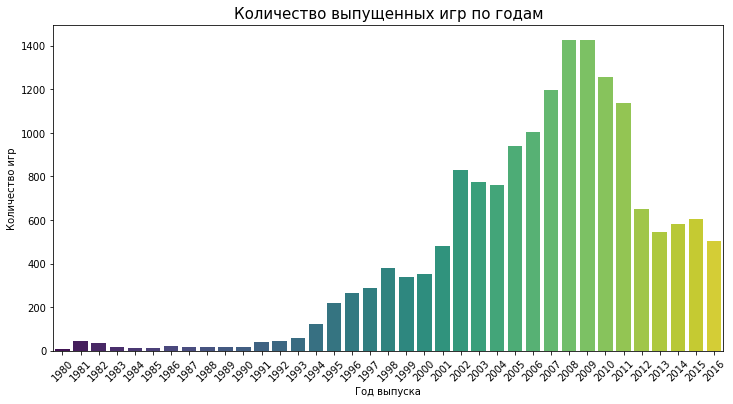

In [28]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=number_of_games_by_year_pivot.index, 
    y=number_of_games_by_year_pivot['name'], 
    palette='viridis')

plt.xlabel('Год выпуска')
plt.ylabel('Количество игр')
plt.title('Количество выпущенных игр по годам', fontsize=15)
plt.xticks(rotation=45)

plt.show()



# Или:
# palette_colors = sns.color_palette("viridis", len(number_of_games_by_year_pivot))

# Построение графика:
# number_of_games_by_year_pivot.plot(kind='bar', grid=True, figsize=(15, 8), color=palette_colors, width=0.8)

# plt.title('Количество выпущенных игр по годам')
# plt.xlabel('Год')
# plt.ylabel('Количество игр')

# plt.show()

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Больше всего игр выпускалось в 2006-2011 года.

### Посмотрим, как менялись продажи по платформам. Выберем платформы с наибольшими суммарными продажами и построим распределение по годам:

In [29]:
top_platforms_pivot = data.pivot_table(index='platform', 
                                       values='total_sales', 
                                       aggfunc='sum'
                                      ).sort_values(by='total_sales', ascending=False)

display(top_platforms_pivot)

,total_sales
platform,
PS2,"1,233.56"
X360,961.24
PS3,931.33
Wii,891.18
DS,802.78
PS,727.58
PS4,314.14
GBA,312.88
PSP,289.53


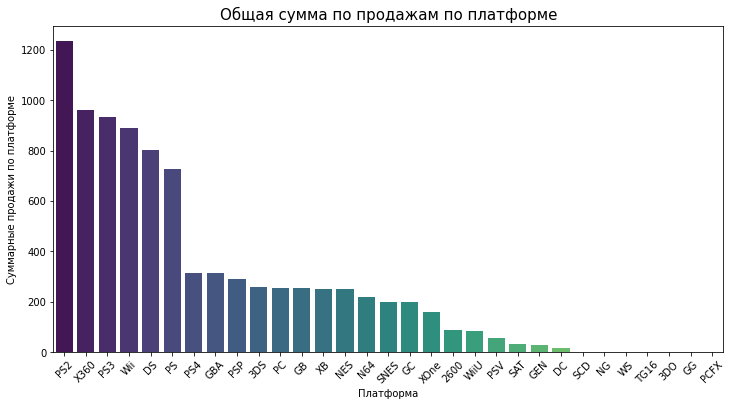

In [30]:
# Создание графика
plt.figure(figsize=(12, 6))

sns.barplot(x=top_platforms_pivot.index, y=top_platforms_pivot['total_sales'], palette='viridis')

plt.xlabel('Платформа')
plt.ylabel('Суммарные продажи по платформе')
plt.title('Общая сумма по продажам по платформе', fontsize=15)
plt.xticks(rotation=45)

plt.show()

Из самых "успешных" по продажам платформ выберем топ-10. Создадим список этих топ-10 платформ:

In [31]:
top_10_platforms = data.pivot_table(index='platform', 
                                    values='total_sales', 
                                    aggfunc='sum').sort_values(
    by='total_sales', ascending=False).reset_index().head(10)['platform'].tolist()

print(f"\nТоп-10 платформ по продажам: {top_10_platforms}")


Топ-10 платформ по продажам: ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'PS4', 'GBA', 'PSP', '3DS']


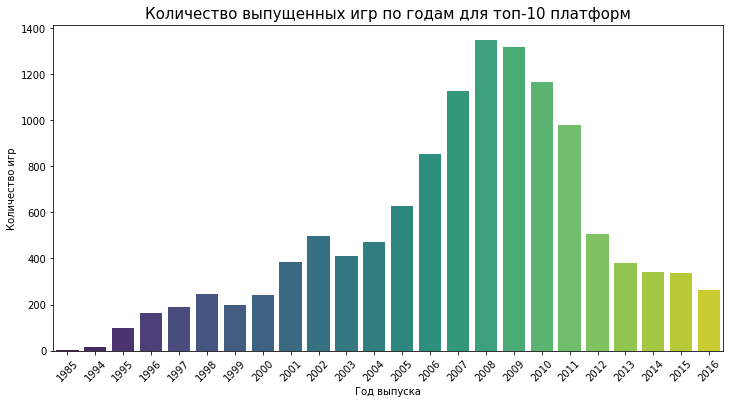

In [32]:
# Посмотрим количество выпущенных только топ-10 игр по годам:
top_10_platforms_data = data[data['platform'].isin(top_10_platforms)]

top_10_platforms_pivot = top_10_platforms_data.pivot_table(
    index=['year_of_release'],
    values='name', 
    aggfunc='count'
).reset_index()

# Создание графика:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_10_platforms_pivot['year_of_release'], 
    y=top_10_platforms_pivot['name'], 
    palette='viridis')

plt.xlabel('Год выпуска')
plt.ylabel('Количество игр')
plt.title('Количество выпущенных игр по годам для топ-10 платформ', fontsize=15)
plt.xticks(rotation=45)

plt.show()

Построим распределение каждой платформы из списка топ-10 по годам:

In [33]:
top_10_platforms_data = data[data['platform'].isin(top_10_platforms)]

top_10_platforms_pivot = top_10_platforms_data.pivot_table(
    index=['year_of_release', 'platform'],
    values='name', 
    aggfunc='count'
)

display(top_10_platforms_pivot)

name
year_of_release platform      
1985            DS           1
1994            PS          17
1995            PS          99
1996            PS         164
1997            PS         188
...                        ...
2016            3DS         46
                PS3         38
                PS4        164
                Wii          1
                X360        13

[97 rows x 1 columns]

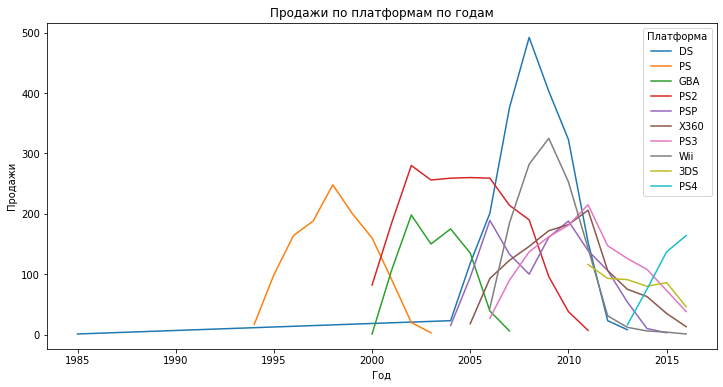

In [34]:
# График продаж по годам для топ-10 платформ:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x='year_of_release', 
    y='name', 
    hue='platform', 
    data=top_10_platforms_pivot
)
plt.title('Продажи по платформам по годам')
plt.xlabel('Год')
plt.ylabel('Продажи')
plt.legend(title='Платформа')
plt.show()

Странный график для платформы игр DS: показан плавный рост продаж с 1985 года по 2004. Вероятнее всего, в данных для этой платформы в данный период присутствуют некорректные данные. 

In [35]:
ds_data = data[data['platform'] == 'DS'].copy()
display(ds_data)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,89,8.50,E,29.80
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,-1,-1.00,not given,24.67
11,Mario Kart DS,DS,2005,Racing,9.71,7.47,4.13,1.90,91,8.60,E,23.21
19,Brain Age: Train Your Brain in Minutes a Day,DS,2005,Misc,4.74,9.20,4.16,2.04,77,7.90,E,20.14
20,Pokemon Diamond/Pokemon Pearl,DS,2006,Role-Playing,6.38,4.46,6.04,1.36,-1,-1.00,not given,18.24
...,...,...,...,...,...,...,...,...,...,...,...,...
16656,Imagine Figure Skater (JP sales),DS,2007,Sports,0.00,0.00,0.01,0.00,-1,-1.00,not given,0.01
16675,Original Frisbee Disc Sports: Ultimate & Golf,DS,2007,Action,0.01,0.00,0.00,0.00,-1,-1.00,not given,0.01
16698,Mega Brain Boost,DS,2008,Puzzle,0.01,0.00,0.00,0.00,48,-1.00,E,0.01
16700,Mezase!! Tsuri Master DS,DS,2009,Sports,0.00,0.00,0.01,0.00,-1,-1.00,not given,0.01


In [36]:
unique_years = ds_data['year_of_release'].unique() 
unique_years = sorted(unique_years) 
print(unique_years) 

[1985, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013]


In [37]:
count_1985 = ds_data[ds_data['year_of_release'] == 1985].shape[0]
print(f"Количество игр платформы DS, выпущенных в 1985 году: {count_1985}")
display(ds_data[ds_data['year_of_release'] == 1985])

Количество игр платформы DS, выпущенных в 1985 году: 1


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
15957,Strongest Tokyo University Shogi DS,DS,1985,Action,0.00,0.00,0.02,0.00,-1,-1.00,not given,0.02


Действительно, указано, что лишь одна игра была выпущена в 1985 году на данной платформе. А потом до 2004 года не было выпущено ни одной игры. 

Оказалось, что игра Strongest Tokyo University Shogi DS была выпущена на PC, а не на DS. В данных ошибка, поскольку платформа DS впервые была выпущена в 2004 году в Японии, а затем позднее уже в Северной Америке и Европе.

**Итого**, мы выявили одно несоответствие реальности в данных. 

Заменим датасет корректным значением данных:

In [38]:
display(data[data['name'] == 'Strongest Tokyo University Shogi DS'])

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
15957,Strongest Tokyo University Shogi DS,DS,1985,Action,0.00,0.00,0.02,0.00,-1,-1.00,not given,0.02


In [39]:
data.loc[15957, 'platform'] = 'PC'
display(data[data['name'] == 'Strongest Tokyo University Shogi DS'])

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
15957,Strongest Tokyo University Shogi DS,PC,1985,Action,0.00,0.00,0.02,0.00,-1,-1.00,not given,0.02


---------------

**Определим, за какой характерный срок появляются новые и исчезают старые платформы:**

In [40]:
data_copy = data.copy() 

# Определим для каждой платформы самую первую дату выпуска игры и самую последнюю дату:
platform_life = data_copy.pivot_table(
    index='platform', 
    values='year_of_release', 
    aggfunc=['min', 'max']
).reset_index()


# Добавим новые столбцы к нашей сводной таблице:
platform_life['life'] = platform_life['max'] - platform_life['min']
display(platform_life)

,platform,min,max,life
,,year_of_release,year_of_release,
0,2600,1980,1989,9
1,3DO,1994,1995,1
2,3DS,2011,2016,5
3,DC,1998,2008,10
4,DS,2004,2013,9
5,GB,1988,2001,13
6,GBA,2000,2007,7
7,GC,2001,2007,6
8,GEN,1990,1994,4


In [41]:
platform_life['life'].mean()

# platform_life['life'].describe()

7.0

В среднем платформы активно выпускают игры в течение 7 лет. 

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>

Платформы с наибольшими суммарными продажами:
PS2	: 1,233.56 ;
X360:	961.24;
PS3:	931.33;
Wii:	891.18;
DS:	802.78;
PS:	727.58;
PS4:	314.14;
    
Мы определили, за какой характерный срок появляются новые и исчезают старые платформы: в среднем платформы активно выпускают игры в течение 8 лет.


### Определим актуальный период, на основании данных которого можно построить прогнозы для игр на 2017 год  :

<div style="border:solid  green 3px; padding: 30px">
    
    
Ранее благодаря среднему значению "жизни" платформы мы определили, что в среднем платформа выпускает игры активно в течение 8 лет. 

Для прогнозирования на 2017 год нам будет достаточно данных за последние 3-4 года, поскольку тенденции и тренды в области компьютерных игр меняются достаточно быстро, поэтому актуальность данных нам будет важна.

Соответственно, **определяем актуальный период** для анализа **с 2013 года по 2016 год**. 

### Определим лидирующие платформы по продажам:

Отфильтруем наш датасет согласно выбранному актуальному периоду:

In [42]:
relevant_data = data[(data['year_of_release'] >= 2013)]

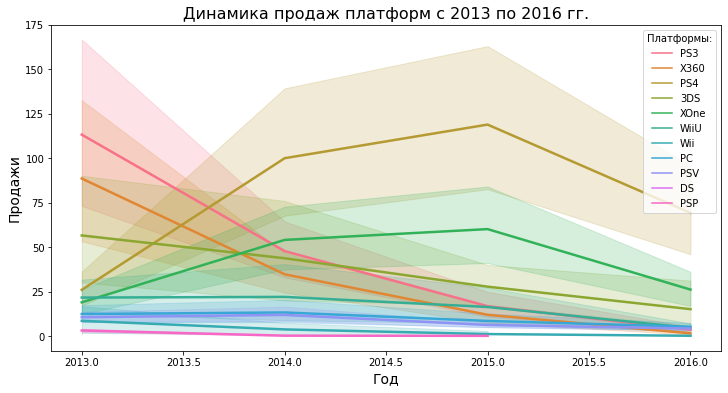

In [43]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x='year_of_release', 
    y='total_sales', 
    hue='platform', 
    data=relevant_data,
    estimator='sum',
    linewidth=2.5
)

plt.title('Динамика продаж платформ с 2013 по 2016 гг.', fontsize=16)
plt.xlabel('Год', fontsize=14)
plt.ylabel('Продажи', fontsize=14)
plt.legend(title='Платформы:')

plt.show()

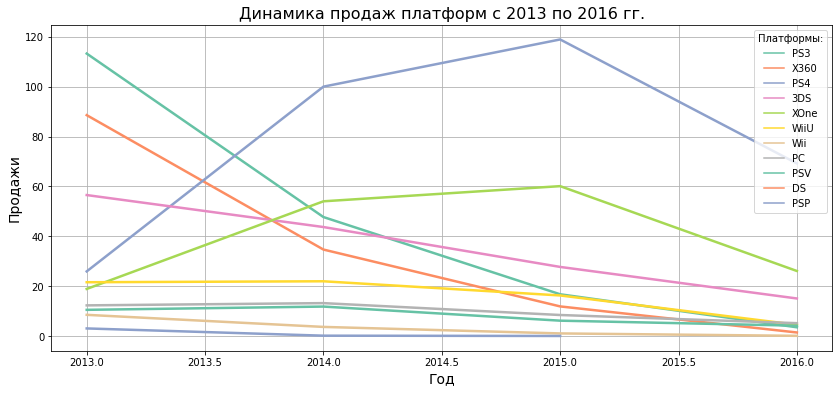

In [44]:
# Уберем доверительный интервал (confidence interval), область вокруг линий, 
# показывющую неопределенность в данных. Используем параметр ci (confidence interval) в значение None:

plt.figure(figsize=(14, 6))

sns.lineplot(
    x='year_of_release', 
    y='total_sales', 
    hue='platform', 
    data=relevant_data,
    estimator='sum', # параметр агрегации: Seaborn по умолчанию будет использовать mean
    linewidth=2.5,
    palette='Set2',
    ci=None  
)

plt.title('Динамика продаж платформ с 2013 по 2016 гг.', fontsize=16)
plt.xlabel('Год', fontsize=14)
plt.ylabel('Продажи', fontsize=14)
plt.legend(title='Платформы:')
plt.grid(True)
plt.show()



<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
Определяя лидирующие платформы по продажам, мы выявили:
    
по графику видно, что в целом с 2013 по 2016 год графики продаж всех платформ идут вниз, то есть продажи падают. Кроме платформ PSP, PC, Wii, PSV, графики которых достаточно стабильны, однако уровни продаж этих платформ являются самым низкими среди представленных платформ. 

Стоит отметить, что продажи платформ PS4 и XOne в начале 2013 года не были лидирующими, но поднялись к 2014 году, продолжали расти до 2015, заняв лидирующие позиции, но затем тенденция стала падать, как и для всех остальных платформ.

Наиболее прибильными платформами являются: PS4, XOne, 3DS, PC, WiiU. 

In [45]:
# Более интерактивный график построим в plotly:

# Группируем данные по годам и платформам:
grouped_data = relevant_data.groupby(['year_of_release', 'platform'], as_index=False)['total_sales'].sum()


# Добавим столбец, который будет показываться при наведении
grouped_data['platform_name_only'] = grouped_data['platform']

fig = px.line(
    grouped_data,
    x='year_of_release',
    y='total_sales',
    color='platform',
    hover_name='platform_name_only',  # отображается при наведении
    hover_data={},  # скрываем остальные данные
    labels={'year_of_release': 'Год', 'total_sales': 'Продажи'}
)

fig.update_layout(
    width=700,
    height=400,
    title='Динамика продаж платформ с 2013 по 2016 гг.',
    legend_title_text='Платформы:',
    hovermode='closest',  # наведение только на точку
    template='plotly_white'
)


### Построим график «ящик с усами» по глобальным продажам игр в разбивке по платформам:

In [46]:
relevant_data['total_sales'].describe()

count   2,233.00
mean        0.49
std         1.24
min         0.01
25%         0.03
50%         0.11
75%         0.40
max        21.05
Name: total_sales, dtype: float64

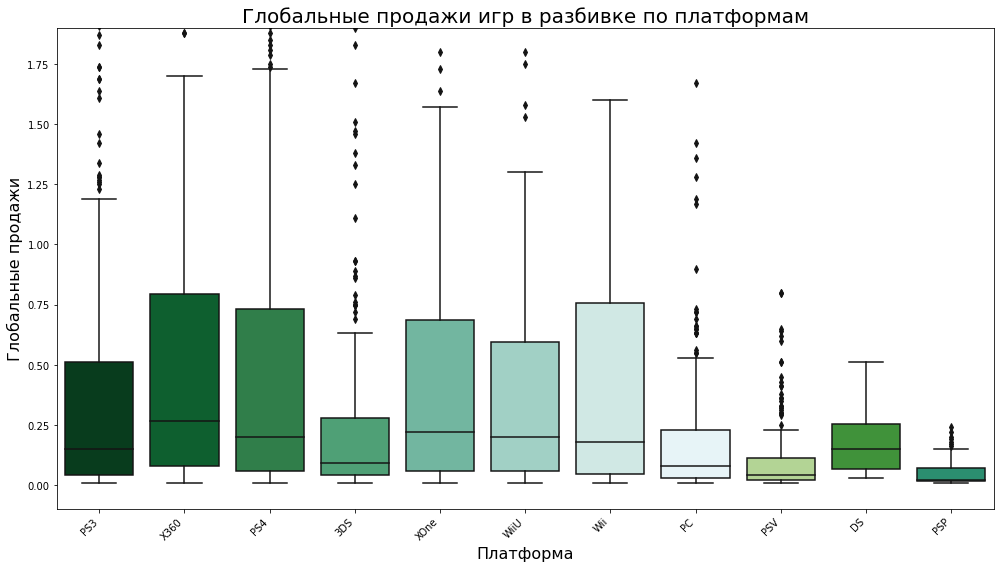

In [47]:
green_palette = [
    '#00441b', '#006d2c', '#238b45', '#41ae76', '#66c2a4',
    '#99d8c9', '#ccece6', '#e5f5f9', '#b2df8a', '#33a02c',
    '#1b9e77', '#66c2a5', '#2ca25f', '#006d2c', '#005824'
]

plt.figure(figsize=(14, 8))

sns.boxplot(x='platform', 
            y='total_sales', 
            data=relevant_data, 
            palette = green_palette)
plt.title('Глобальные продажи игр в разбивке по платформам', fontsize=20)
plt.xlabel('Платформа', fontsize=16)
plt.ylabel('Глобальные продажи', fontsize=16)
plt.ylim(-0.1, 1.9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Согласно графикам, мы видим, что по медианным показателям ящиков с усами такие консоли, как X360, PS4, XOne, WiiU и Wii наиболее прибыльные.

### Посмотрим, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков:

Построим диаграмму рассеяния и посчитаем корреляцию между отзывами и продажами:

Отфильтруем данные:

In [48]:
filtered_relevant_data = relevant_data[(
    relevant_data['critic_score'] > 0) & 
    (relevant_data['user_score'] > 0) & 
    (relevant_data['total_sales'] > 0
    )]

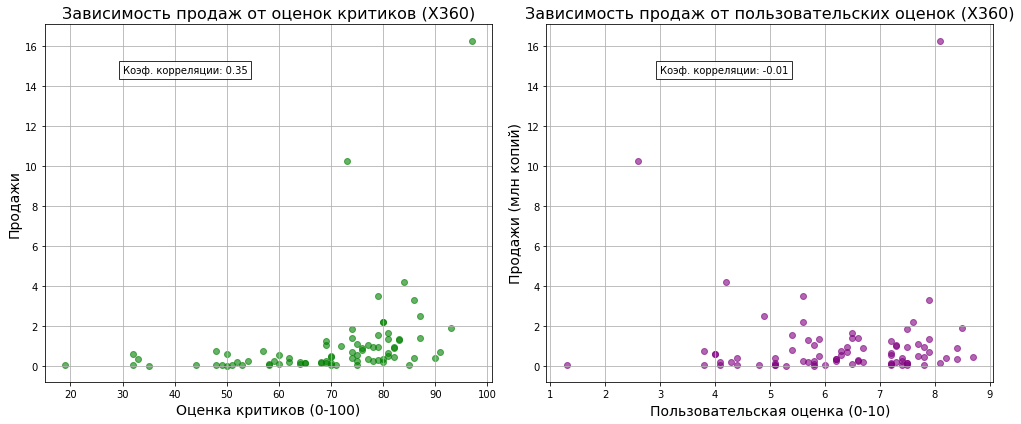

In [49]:
# Оставляем только платформу X360:
x360_data = filtered_relevant_data[filtered_relevant_data['platform'] == 'X360'].copy()


# Построим графики:
plt.figure(figsize=(14, 6))



# График 1: Critic Score vs Total Sales:
plt.subplot(1, 2, 1)
plt.scatter(x360_data['critic_score'], x360_data['total_sales'], alpha=0.6, color='green')
plt.title('Зависимость продаж от оценок критиков (X360)', fontsize=16)
plt.xlabel('Оценка критиков (0-100)', fontsize=14)
plt.ylabel('Продажи', fontsize=14)
plt.grid(True)

# Корреляция критиков:
corr_critic = round(x360_data['critic_score'].corr(x360_data['total_sales']), 2)
plt.text(30, x360_data['total_sales'].max()*0.9,
         f'Коэф. корреляции: {corr_critic}',
         bbox=dict(facecolor='white', alpha=0.8))


# График 2: User Score vs Total Sales:
plt.subplot(1, 2, 2)
plt.scatter(x360_data['user_score'], x360_data['total_sales'], alpha=0.6, color='purple')
plt.title('Зависимость продаж от пользовательских оценок (X360)', fontsize=16)
plt.xlabel('Пользовательская оценка (0-10)', fontsize=14)
plt.ylabel('Продажи (млн копий)', fontsize=14)
plt.grid(True)

# Корреляция пользователей:
corr_user = round(x360_data['user_score'].corr(x360_data['total_sales']), 2)
plt.text(3, x360_data['total_sales'].max()*0.9, 
         f'Коэф. корреляции: {corr_user}',
         bbox=dict(facecolor='white', alpha=0.8))



plt.tight_layout()
plt.show()

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Судя по графикам рассеяния и коэффициентам корреляции, мы можем сказать, что "сила связи" между рассматриваемыми переменными слабая: в случае корреляции между critic_score и total_sales связь слабая, но положительная (0.35), а в случае корреляции между user_score и total_sales связь слабая и отрицательная. 
    
В целом, связь есть между оценками критиков и уровнем продаж, но не сильная, а вот связь между оценкой пользователей и уровнем продаж связи не прослеживается для платформы X360. 

**Соотнесем выводы с продажами игр на других платформах:**

In [50]:
# Создадим функцию для отображения таких же графиков но для списка некоторых других платформ:

def plot_sales_vs_scores(data, platforms):
    for platform in platforms:
        platform_data = data[data['platform'] == platform].copy()
        
        if platform_data.empty:
            print(f"Нет данных для платформы {platform}")
            continue

        plt.figure(figsize=(14, 6))
        plt.suptitle(f'Платформа: {platform}', fontsize=22)

        # График 1: Critic Score vs Total Sales
        plt.subplot(1, 2, 1)
        plt.scatter(platform_data['critic_score'], platform_data['total_sales'], alpha=0.6, color='green')
        plt.title('Зависимость продаж от оценок критиков', fontsize=14)
        plt.xlabel('Оценка критиков (0-100)', fontsize=12)
        plt.ylabel('Продажи (млн копий)', fontsize=12)
        plt.grid(True)

        corr_critic = round(platform_data['critic_score'].corr(platform_data['total_sales']), 2)
        plt.text(30, platform_data['total_sales'].max()*0.9,
                 f'Коэф. корреляции: {corr_critic}',
                 bbox=dict(facecolor='white', alpha=0.8))

        # График 2: User Score vs Total Sales
        plt.subplot(1, 2, 2)
        plt.scatter(platform_data['user_score'], platform_data['total_sales'], alpha=0.6, color='purple')
        plt.title('Зависимость продаж от пользовательских оценок', fontsize=14)
        plt.xlabel('Пользовательская оценка (0-10)', fontsize=12)
        plt.ylabel('Продажи (млн копий)', fontsize=12)
        plt.grid(True)

        corr_user = round(platform_data['user_score'].corr(platform_data['total_sales']), 2)
        plt.text(3, platform_data['total_sales'].max()*0.9,
                 f'Коэф. корреляции: {corr_user}',
                 bbox=dict(facecolor='white', alpha=0.8))

        plt.tight_layout(rect=[0, 0, 1, 0.95])  # чтобы не наезжало на заголовок
        plt.show()

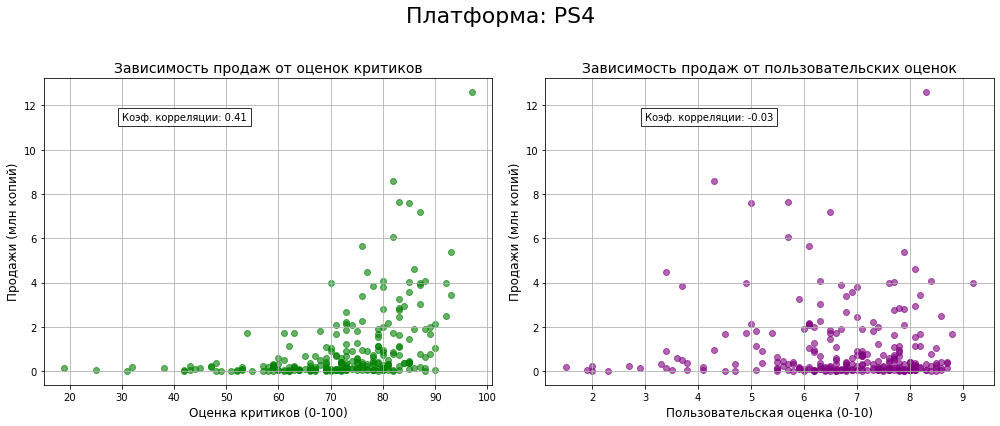

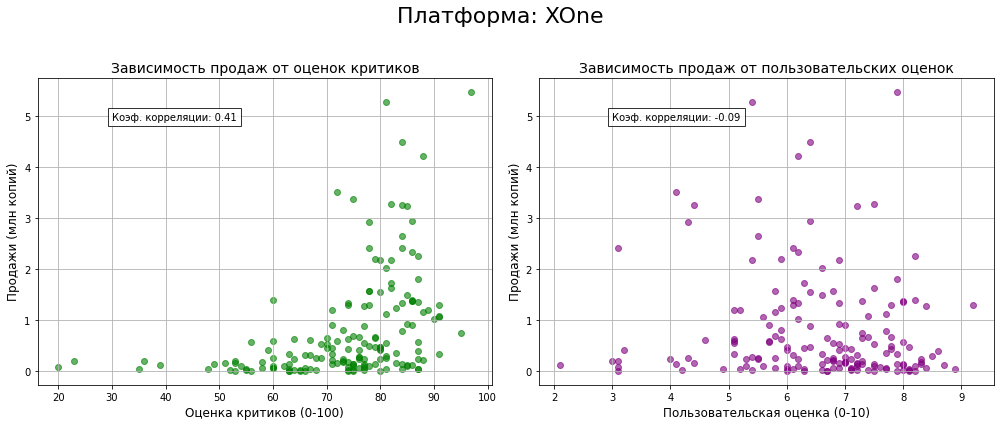

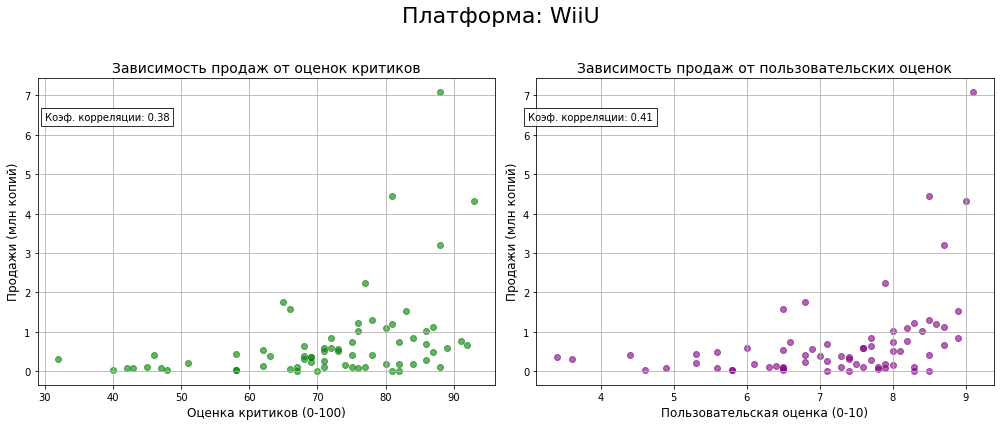

In [51]:
best_platforms = ['PS4', 'XOne', 'WiiU']
plot_sales_vs_scores(filtered_relevant_data, best_platforms)

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
1) Для платформы PS4: 
    
- Коэффициент корреляции между оценкой критиков и продажами: 0.41
    
- Коэффициент корреляции между оценкой пользователей и продажами: - 0.03
    
    

2) Для платформы XOne: 
    
- Коэффициент корреляции между оценкой критиков и продажами: 0.41
    
- Коэффициент корреляции между оценкой пользователей и продажами: - 0.09
    
  

2) Для платформы WiiU: 
    
- Коэффициент корреляции между оценкой критиков и продажами: 0.38
    
- Коэффициент корреляции между оценкой пользователей и продажами: 0.41
    

Таким образом, для остальных платформ тенденция связи между оценкой критиков и продажами умеренно положительная, не сильная. То есть связь есть, оценка критиков умеренно влияет на продажи внутри платформ, чем выше оценка, тем продажи в целом повыше. 
  
Однако связь между оценками пользователей и продажами для большинства платформ отрицательная и слабее, то есть связи между переменными нет. Исключение составляет связь между оценками пользователей и продажами внутри платформы WiiU: корреляция между пользовательскими оценками и продажами здесь положительная, умеренная, даже чуть сильнее, чем связь между оценками критиков и продажами.
    
<b>По полученным данным, делаем вывод, что сильной зависимости между параметрами нет, но оценки критиков учитываются в большей степени, чем оценки пользователей.</b>

### Посмотрим на общее распределение игр по жанрам:

In [52]:
# best_genres = relevant_data.groupby('genre')['total_sales'].median().sort_values(ascending=False)

genres_pivot = relevant_data.pivot_table(
    index='genre', 
    values='total_sales', 
    aggfunc={'total_sales': ['sum', 'mean', 'median']}
)

display(genres_pivot.sort_values('sum', ascending=False))  

,mean,median,sum
genre,,,
Action,0.42,0.11,321.87
Shooter,1.25,0.45,232.98
Sports,0.70,0.24,150.65
Role-Playing,0.50,0.12,145.89
Misc,0.41,0.10,62.82
Platform,0.58,0.22,42.63
Racing,0.47,0.12,39.89
Fighting,0.44,0.12,35.31
Adventure,0.10,0.03,23.64


In [53]:
# Убираем вложенность в названиях столбцов:
genres_pivot.columns = ['mean_sales', 'median_sales', 'sum_sales']

Сортируем по сумме продаж:

In [54]:
display(genres_pivot.sort_values('sum_sales', ascending=False))  

,mean_sales,median_sales,sum_sales
genre,,,
Action,0.42,0.11,321.87
Shooter,1.25,0.45,232.98
Sports,0.70,0.24,150.65
Role-Playing,0.50,0.12,145.89
Misc,0.41,0.10,62.82
Platform,0.58,0.22,42.63
Racing,0.47,0.12,39.89
Fighting,0.44,0.12,35.31
Adventure,0.10,0.03,23.64


Сортируем по медиане продаж:

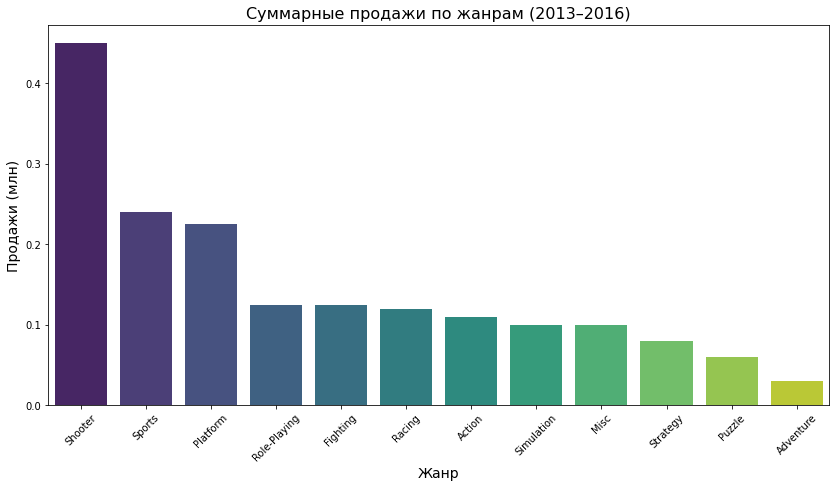

In [55]:
genres_pivot_sorted = genres_pivot.sort_values('median_sales', ascending=False)

# График продаж по жанрам:
plt.figure(figsize=(14, 7))
sns.barplot(
    x=genres_pivot_sorted.index,
    y=genres_pivot_sorted['median_sales'],
    palette='viridis'
)

plt.title('Суммарные продажи по жанрам (2013–2016)', fontsize=16)
plt.xlabel('Жанр', fontsize=14)
plt.ylabel('Продажи (млн)', fontsize=14)
plt.xticks(rotation=45)
plt.show()


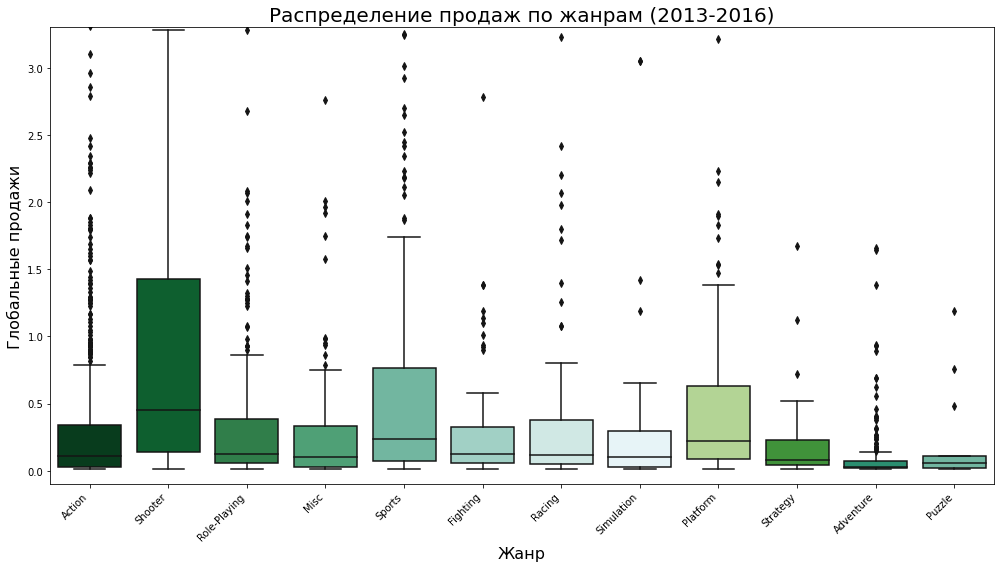

In [56]:
plt.figure(figsize=(14, 8))

sns.boxplot(x='genre', 
            y='total_sales', 
            data=relevant_data, 
            palette = green_palette)

plt.title('Распределение продаж по жанрам (2013-2016)', fontsize=20)
plt.xlabel('Жанр', fontsize=16)
plt.ylabel('Глобальные продажи', fontsize=16)
plt.ylim(-0.1, 3.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

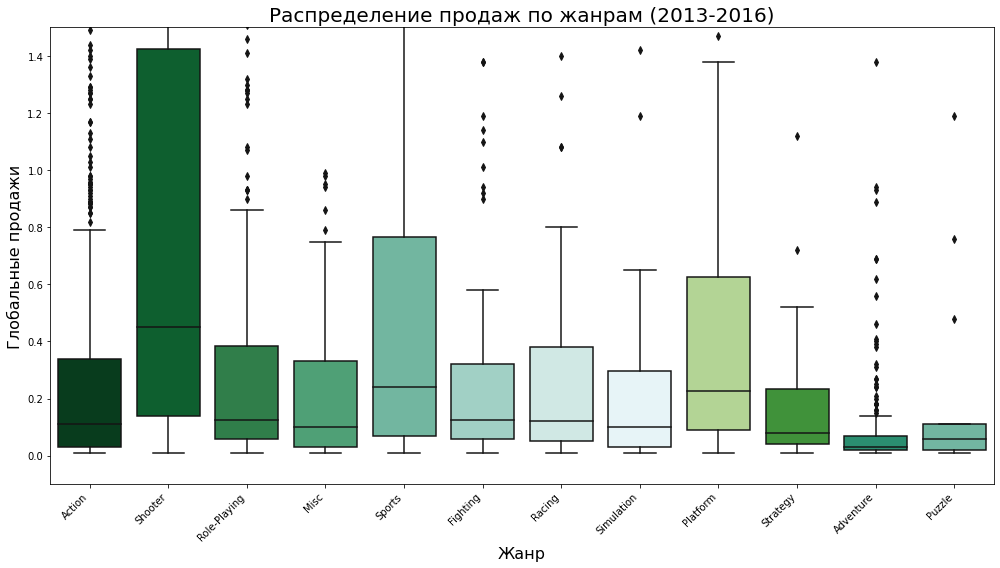

In [57]:
plt.figure(figsize=(14, 8))

sns.boxplot(x='genre', 
            y='total_sales', 
            data=relevant_data, 
            palette = green_palette)

plt.title('Распределение продаж по жанрам (2013-2016)', fontsize=20)
plt.xlabel('Жанр', fontsize=16)
plt.ylabel('Глобальные продажи', fontsize=16)
plt.ylim(-0.1, 1.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

Отсортируем по убыванию медиан:

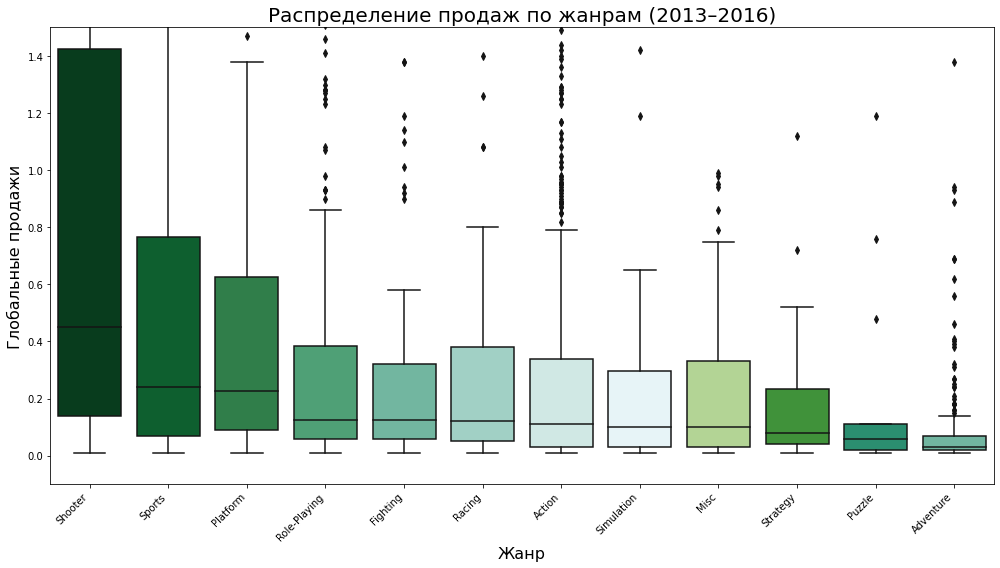

In [58]:
# Вычисляем медиану продаж по жанрам:
median_sales = relevant_data.groupby('genre')['total_sales'].median().sort_values(ascending=False)

plt.figure(figsize=(14, 8))

sns.boxplot(
    x='genre', 
    y='total_sales', 
    data=relevant_data, 
    palette=green_palette,
    order=median_sales.index  # <-- сортировка по медиане
)

plt.title('Распределение продаж по жанрам (2013–2016)', fontsize=20)
plt.xlabel('Жанр', fontsize=16)
plt.ylabel('Глобальные продажи', fontsize=16)
plt.ylim(-0.1, 1.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>

Согласно полученным данным, по сумме продаж, лидирующим жанром игр является Action (321.87 мл.н), далее идут жанры Shooter (232.98 млн.) и Sports ( 150.65 млн.).
    
Исходя же из графиков медианных продаж, мы можем заметить, что наиболее прибыльным жанром является Shooter. Второе и третье места занимают жанры Sports и Platform моответственно. Однако их медианные продажи почти в 2 раза меньше, чем у жанра-лидера.

Если посмотреть на диаграммы размаха, то можно понять, почему без аггрегации первое место по продажам занимал жанр Action: при меньшем количестве игр данный жанр имеет колоссальные выбросы продаж в сравнении с другими жанрами. Это может говорить о том, что игры данного жанра зачастую являются хитами.
    
Самые низкие продажи у жанров Adventure, Simulation, Strategy, Puzzle.

<div style="border:solid  green 6px; padding: 30px">
    
<b> ВЫВОД:</b>
  
Анализ рынка видеоигр за период с 2013 по 2016 год показал, что индустрия в целом находилась в стадии спада: продажи большинства платформ постепенно снижались. Тем не менее, платформы PS4, XOne и WiiU успели занять лидирующие позиции в этот период, показывая рост до 2015 года, прежде чем также столкнуться с падением интереса. Платформы PS4, XOne, 3DS, PC и WiiU стали наиболее прибыльными за рассматриваемый период, как по общим продажам, так и по медианным значениям в распределении.

Корреляционный анализ внутри платформ подтвердил: оценки критиков имеют слабую, но стабильную положительную связь с продажами, особенно для PS4, XOne и WiiU. Влияние оценок пользователей оказалось менее значимым, и в большинстве случаев либо не прослеживается вовсе, либо имеет слабую отрицательную корреляцию. Исключением является WiiU, где отзывы пользователей также умеренно положительно связаны с продажами.

По жанрам, лидером по суммарным продажам стал жанр Action, однако по медианным продажам и стабильности выручки первое место занимает жанр Shooter, за которым следуют Sports и Platform. Это свидетельствует о том, что Action-игры чаще становятся громкими хитами, но в целом уступают в стабильности другим жанрам. Наименьшие продажи традиционно показывают жанры Adventure, Simulation, Strategy и Puzzle.

Таким образом, главные факторы, которые в большей степени влияют на продажи, — это платформа, жанр и оценка критиков. Пользовательские оценки, несмотря на интуитивную значимость, практически не оказывают заметного влияния на уровень продаж большинства игр.
    

## Шаг 4. Портрет пользователя каждого региона

###  Определим для пользователя каждого региона (NA, EU, JP):

####  Самые популярные платформы (топ-5):

Опишем различия в долях продаж:

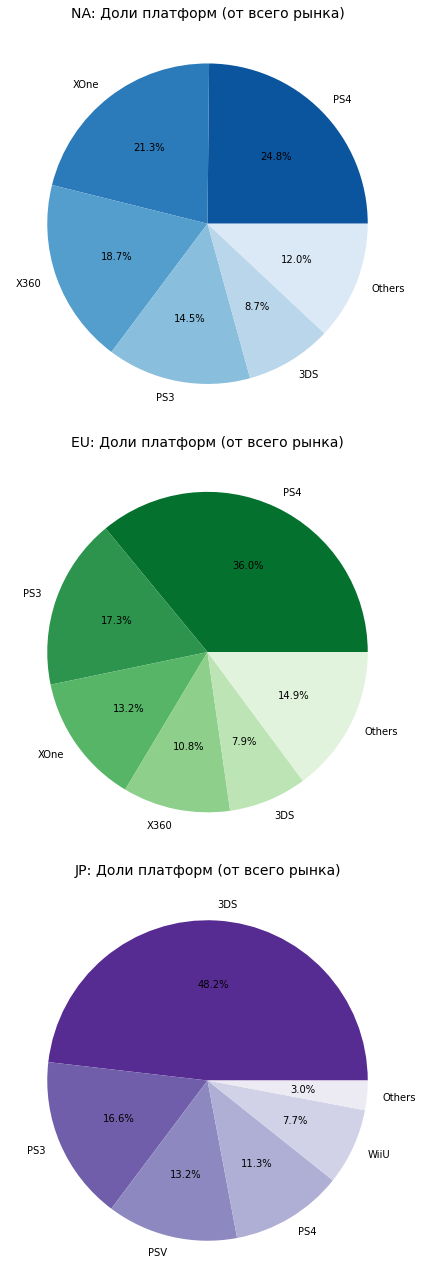

In [59]:
plt.figure(figsize=(10, 18)) 

# === СЕВЕРНАЯ АМЕРИКА ===
na_sales = relevant_data.groupby('platform')['na_sales'].sum().sort_values(ascending=False)
na_top_5 = na_sales.head(5)
na_others = pd.Series({'Others': na_sales[5:].sum()})
na_combined = pd.concat([na_top_5, na_others])

plt.subplot(3, 1, 1)
colors_na = sns.color_palette("Blues", len(na_combined))[::-1]  # яркий цвет палитры — макс. доля
plt.pie(na_combined, labels=na_combined.index, autopct='%1.1f%%', colors=colors_na)
plt.title('NA: Доли платформ (от всего рынка)', fontsize=14)


# === ЕВРОПА ===
eu_sales = relevant_data.groupby('platform')['eu_sales'].sum().sort_values(ascending=False)
eu_top_5 = eu_sales.head(5)
eu_others = pd.Series({'Others': eu_sales[5:].sum()})
eu_combined = pd.concat([eu_top_5, eu_others])

plt.subplot(3, 1, 2)
colors_eu = sns.color_palette("Greens", len(eu_combined))[::-1]
plt.pie(eu_combined, labels=eu_combined.index, autopct='%1.1f%%', colors=colors_eu)
plt.title('EU: Доли платформ (от всего рынка)', fontsize=14)


# === ЯПОНИЯ ===
jp_sales = relevant_data.groupby('platform')['jp_sales'].sum().sort_values(ascending=False)
jp_top_5 = jp_sales.head(5)
jp_others = pd.Series({'Others': jp_sales[5:].sum()})
jp_combined = pd.concat([jp_top_5, jp_others])

plt.subplot(3, 1, 3)
colors_jp = sns.color_palette("Purples", len(jp_combined))[::-1]
plt.pie(jp_combined, labels=jp_combined.index, autopct='%1.1f%%', colors=colors_jp)
plt.title('JP: Доли платформ (от всего рынка)', fontsize=14)

plt.tight_layout()
plt.show()

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Согласно круговым диаграммам видно, что для:
    
1. Северной Америки: 
    
Популярными топ-5 платформами являются: PS4 (24.8%), XOne (21.3%), X360 (18.7%), PS3 (14.5%), 3DS (8.7%).

2. Европы:

Лидирующими топ-5 платформами являются: PS4 (36%), PS3 (17.3%), XOne (13.2%), X360 (10.8%),  3DS (7.9%).

3. Японии:
    
Популярными топ-5 платформами являются: 3DS (48.2%), PS3 (16.6%), PSV (13.2%), PS4 (11.3%), WiiU (7.7%).
    

Для Северной Америки и Европы PS4 является лидером среди игровых консолей. Для Японии же абсолютным лидером, доля которого составляет почти половину всех игровых платформ страны, является 3DS. WiiU вошла в топ-5 консолей Японии, но не Северной Америки и Европы.
    
Возможно, разница в долях связана с культурными различиями (в Японии портативные системы пользуются большей популярностью).

####  Самые популярные жанры (топ-5):

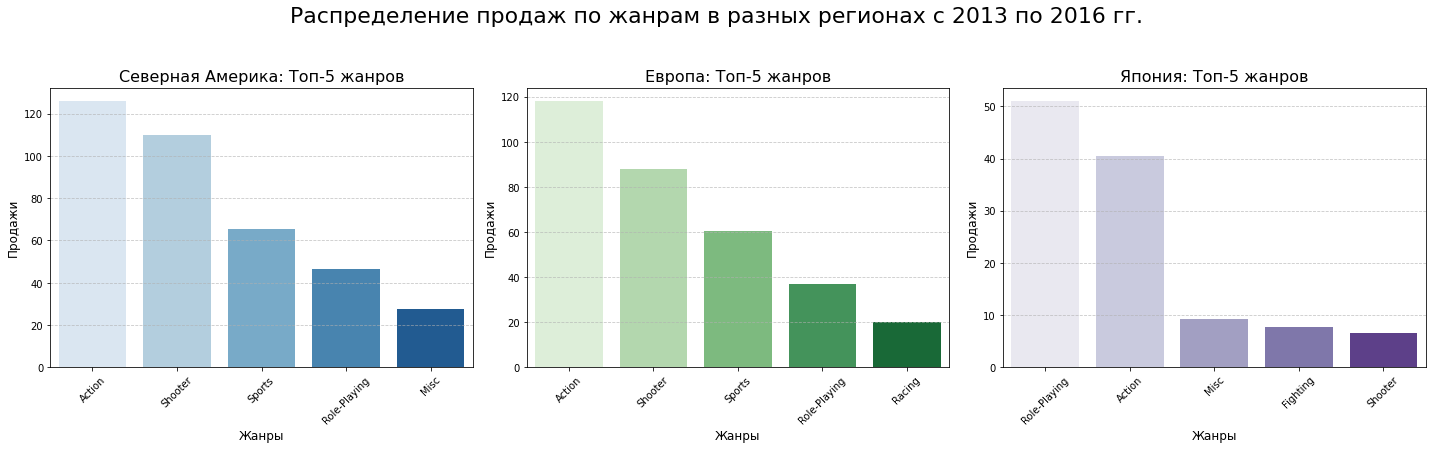

In [60]:
plt.figure(figsize=(20, 15))
plt.suptitle('Распределение продаж по жанрам в разных регионах с 2013 по 2016 гг.', fontsize=22, y=1.02)

# === СЕВЕРНАЯ АМЕРИКА ===
plt.subplot(3, 3, 1)
na_genres = relevant_data.groupby('genre')['na_sales'].sum().nlargest(5)

sns.barplot(
    x=na_genres.index, 
    y=na_genres.values, 
    palette="Blues",
    order=na_genres.index # чтобы сохранить порядок жанров по убыванию по индексам, а не по умолчанию в алфавитном порядке 
)
plt.title('Северная Америка: Топ-5 жанров', fontsize=16)
plt.xlabel('Жанры', fontsize=12)
plt.ylabel('Продажи', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# === ЕВРОПА ===
plt.subplot(3, 3, 2)
eu_genres = relevant_data.groupby('genre')['eu_sales'].sum().nlargest(5)

sns.barplot(
    x=eu_genres.index, 
    y=eu_genres.values, 
    palette="Greens",
    order=eu_genres.index
)
plt.title('Европа: Топ-5 жанров', fontsize=16)
plt.xlabel('Жанры', fontsize=12)
plt.ylabel('Продажи', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# === ЯПОНИЯ ===
plt.subplot(3, 3, 3)
jp_genres = relevant_data.groupby('genre')['jp_sales'].sum().nlargest(5)

sns.barplot(
    x=jp_genres.index, 
    y=jp_genres.values, 
    palette="Purples",
    order=jp_genres.index
)
plt.title('Япония: Топ-5 жанров', fontsize=16)
plt.xlabel('Жанры', fontsize=12)
plt.ylabel('Продажи', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Согласно полученным данным по распределению продаж по жанрам в разных регионах, можно заключить, что:
    
для Северной Америки И Европы самым популярным жанром является Action, далее Scooter и Sports, а для Японии Role-playing. Жанр Action для Японии стоит на втором месте. для Северной Америки и Европы же Role-playing стоит на 4-м месте. 
    
Наименее популярным жанром в Японии является Scooter, причем пополярность его почти в 5 раз меньше, чем жанр-лидер в регионе. 
    
Для Америки и Европы наименее популярными жанрами являются Misc и Racing. 


####  Влияет ли рейтинг ESRB на продажи в отдельном регионе?

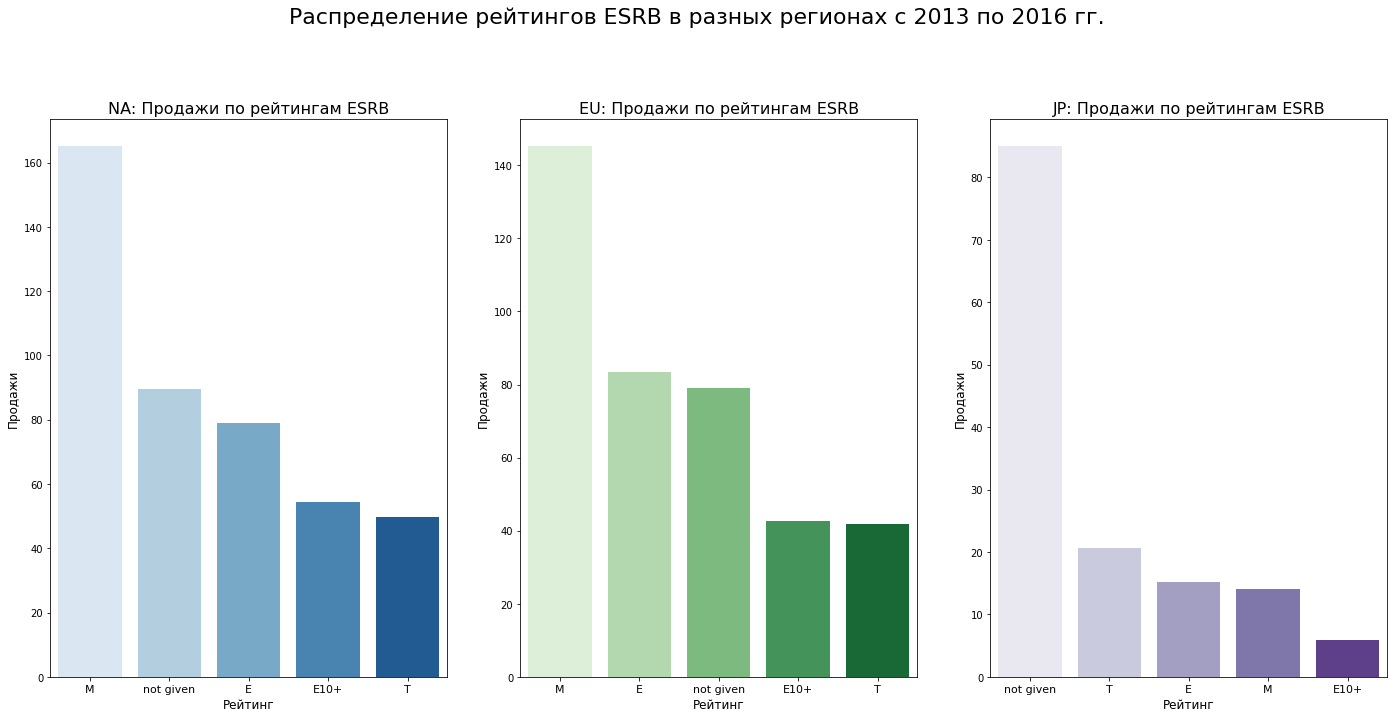

In [61]:
plt.figure(figsize=(20, 10))
plt.suptitle('Распределение рейтингов ESRB в разных регионах с 2013 по 2016 гг.', fontsize=22, y=1.02)

# === СЕВЕРНАЯ АМЕРИКА ===
plt.subplot(1, 3, 1)
na_ratings = relevant_data.groupby('rating')['na_sales'].sum().sort_values(ascending=False)

sns.barplot(
    x=na_ratings.index, 
    y=na_ratings.values, 
    palette="Blues", 
    order=na_ratings.index
)
plt.title('NA: Продажи по рейтингам ESRB', fontsize=16)
plt.xlabel('Рейтинг', fontsize=12)
plt.ylabel('Продажи', fontsize=12)
plt.xticks(fontsize=11)

# === ЕВРОПА ===
plt.subplot(1, 3, 2)
eu_ratings = relevant_data.groupby('rating')['eu_sales'].sum().sort_values(ascending=False)

sns.barplot(
    x=eu_ratings.index, 
    y=eu_ratings.values, 
    palette="Greens", 
    order=eu_ratings.index
)
plt.title('EU: Продажи по рейтингам ESRB', fontsize=16)
plt.xlabel('Рейтинг', fontsize=12)
plt.ylabel('Продажи', fontsize=12)
plt.xticks(fontsize=11)

# === ЯПОНИЯ ===
plt.subplot(1, 3, 3)
jp_ratings = relevant_data.groupby('rating')['jp_sales'].sum().sort_values(ascending=False)

sns.barplot(
    x=jp_ratings.index, 
    y=jp_ratings.values, 
    palette="Purples", 
    order=jp_ratings.index
)
plt.title('JP: Продажи по рейтингам ESRB', fontsize=16)
plt.xlabel('Рейтинг', fontsize=12)
plt.ylabel('Продажи', fontsize=12)
plt.xticks(fontsize=11)

plt.tight_layout(pad=3.0)
plt.show()

<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>
    
Касательно рейтинга ESRB (Entertainment Software Rating Board), мы обнаружили, что :
    
рейтинги у Северной Америки и Европы идентичные (за исключением того, что для Серевной Америки категория рейтинга not given более многочисленная, нежели чем для Европы).
    
А так, рейтинг М (Mature) самый популярный для регионов Северной Америки и Европы. В почти 2 разща менее популярны игры с рейтингов Е (Everyone). Конечно же, это наиболее универсиальные и расчитанные на более многочисленный диапазон населения, поэтому и продажи таких игр более популярные. 
    
Что касается Японии, то здесь игры без рейтинга показывают самые высокие результаты по продажам. Остальные рейтинги представлены в немногочисленных цифрах. Это может быть в целом связано с тем, что ESRB - система рейтингов для видеоигр используется в основном в Северной Америке. В Японии же используется другая система рейтингов — CERO (Computer Entertainment Rating Organization).CERO выполняет аналогичные функции, как ESRB, но учитывает культурные и социальные особенности Японии. Поэтому, хотя игры с рейтингом ESRB немного продаются в Японии, сама система ESRB не является распространенной.

<div style="border:solid  green 6px; padding: 30px">
    
<b> ВЫВОД:</b>
    
Определяя портрет для пользователя каждого региона (NA, EU, JP), мы обнаружили следующую картину:
    
1. Касательно самых популярных платформ:
   
Для Северной Америки:
Популярными топ-5 платформами являются: PS4 (24.8%), XOne (21.3%), X360 (18.7%), PS3 (14.5%), 3DS (8.7%).

Для Европы:
Лидирующими топ-5 платформами являются: PS4 (36%), PS3 (17.3%), XOne (13.2%), X360 (10.8%), 3DS (7.9%).

Для Японии:
Популярными топ-5 платформами являются: 3DS (48.2%), PS3 (16.6%), PSV (13.2%), PS4 (11.3%), WiiU (7.7%).

Для Северной Америки и Европы PS4 является лидером среди игровых консолей. Для Японии же абсолютным лидером, доля которого составляет почти половину всех игровых платформ страны, является 3DS. WiiU вошла в топ-5 консолей Японии, но не Северной Америки и Европы.

Возможно, разница в долях связана с культурными различиями (в Японии портативные системы пользуются большей популярностью).


2. Касательно самых популярных жанро (топ-5):

для Северной Америки И Европы самым популярным жанром является Action, далее Scooter и Sports, а для Японии Role-playing. Жанр Action для Японии стоит на втором месте. для Северной Америки и Европы же Role-playing стоит на 4-м месте.

Наименее популярным жанром в Японии является Scooter, причем пополярность его почти в 5 раз меньше, чем жанр-лидер в регионе.

Для Америки и Европы наименее популярными жанрами являются Misc и Racing.


3. Касательно рейтинга ESRB и его влияния на продажи в отдельном регионе:
мы обнаружили, что :

рейтинги у Северной Америки и Европы идентичные (за исключением того, что для Серевной Америки категория рейтинга not given более многочисленная, нежели чем для Европы).

А так, рейтинг М (Mature) самый популярный для регионов Северной Америки и Европы. В почти 2 разща менее популярны игры с рейтингов Е (Everyone). Конечно же, это наиболее универсиальные и расчитанные на более многочисленный диапазон населения, поэтому и продажи таких игр более популярные.

Что касается Японии, то здесь игры без рейтинга показывают самые высокие результаты по продажам. Остальные рейтинги представлены в немногочисленных цифрах. Это может быть в целом связано с тем, что ESRB - система рейтингов для видеоигр используется в основном в Северной Америке. В Японии же используется другая система рейтингов — CERO (Computer Entertainment Rating Organization).CERO выполняет аналогичные функции, как ESRB, но учитывает культурные и социальные особенности Японии. Поэтому, хотя игры с рейтингом ESRB немного продаются в Японии, сама система ESRB не является распространенной.

## Шаг 5. Проверка гипотез

###  Средние пользовательские рейтинги платформ Xbox One и PC одинаковые:

**Формулируем гипотезы:**

- H₀ (нулевая гипотеза): μ₁ = μ₂ (средние пользовательские рейтинги Xbox One и PC одинаковые)
- H₁ (альтернативная гипотеза): μ₁ ≠ μ₂ (средние пользовательские рейтинги Xbox One и PC разные)

Создадим два среза:

In [62]:
# 1) Для XOne:
xone_us = relevant_data[(relevant_data['platform'] == 'XOne') & (relevant_data['user_score'] > 0)]
xone_us['user_score'].describe()

count   182.00
mean      6.52
std       1.38
min       1.60
25%       5.80
50%       6.80
75%       7.50
max       9.20
Name: user_score, dtype: float64

In [63]:
# 2) Для PC:
pc_us = relevant_data[(relevant_data['platform'] == 'PC') & (relevant_data['user_score'] > 0)]
pc_us['user_score'].describe()

# pc_us = relevant_data.query("platform == 'PC' and user_score > 0")

count   155.00
mean      6.27
std       1.74
min       1.40
25%       5.30
50%       6.80
75%       7.60
max       9.30
Name: user_score, dtype: float64

- Средний пользовательский рейтинг платформы Xbox One: 6.52

- Средний пользовательский рейтинг платформы PC: 6.27

**Используем тест Стюдента:**
в данном случае: двусторонний t-тест

In [64]:
# зададим уровень значимости:
alpha = 0.05

results = st.ttest_ind(xone_us['user_score'], pc_us['user_score'], equal_var=False) # alternative='two-sided'
print(f'p-value: {results.pvalue}')


if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нулевую гипотезу НЕ отвергаем')

    
# Или так:
# xone_us = relevant_data[(relevant_data['platform'] == 'XOne') & (relevant_data['user_score'] > 0)]['user_score']
# pc_us = relevant_data[(relevant_data['platform'] == 'PC') & (relevant_data['user_score'] > 0)]['user_score']

# alpha = 0.05
# results = st.ttest_ind(xone_us, pc_us, equal_var=False) # alternative='two-sided'
# print(f'p-value: {results.pvalue}')
# и т.д.

p-value: 0.14759594013430463
Нулевую гипотезу НЕ отвергаем


<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>

Не удалось отвергнуть нулевую гипотезу при уровне значимости alpha = 0.05, следовательно, мы можем предположить, что средние пользовательские рейтинги платформ Xbox One и PC равны. 

Это вполне совпадаем с реальностью, ведь рассчитав средние значения пользовательских оценок для двух платформ, мы заметили, что их значения почти равны:  6.52 VS 6.27 .

###  Средние пользовательские рейтинги жанров Action («действие», экшен-игры) и Sports («спортивные соревнования») разные:

**Формулируем гипотезы:**

- H₀ (нулевая гипотеза): μ₁ = μ₂ (средние пользовательские рейтинги Action и Sports одинаковые)
- H₁ (альтернативная гипотеза): μ₁ ≠ μ₂ (средние пользовательские рейтинги Action и Sports разные)

Создадим два среза:

In [65]:
# 1) Для Action:
action_us = relevant_data[(relevant_data['genre'] == 'Action') & (relevant_data['user_score'] > 0)]['user_score']
action_us.describe()

count   389.00
mean      6.84
std       1.33
min       2.00
25%       6.30
50%       7.10
75%       7.80
max       9.10
Name: user_score, dtype: float64

In [66]:
# 2) Для Sports:
sports_us = relevant_data[(relevant_data['genre'] == 'Sports') & (relevant_data['user_score'] > 0)]['user_score']
sports_us.describe()

count   160.00
mean      5.24
std       1.78
min       0.20
25%       4.10
50%       5.50
75%       6.50
max       8.80
Name: user_score, dtype: float64

Запустим тест:

In [67]:
alpha = 0.05
results = st.ttest_ind(action_us, sports_us, equal_var=False)

print(f'p-value: {results.pvalue}')

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нулевую гипотезу НЕ отвергаем')

p-value: 1.4460039700704315e-20
Отвергаем нулевую гипотезу


<div style="border:solid  green 3px; padding: 30px">
    
<b> ИТОГО:</b>

Нулевая гипотеза о равенстве средних пользовательских рейтинга Action и Sports была отвергнута при alpha=0.05. Мы можем с уверенностью сказать, что пользовательские рейтинги этих жанров различаются 

<div style="border:solid  green 6px; padding: 30px">
    
<b> ВЫВОД:</b>
    
Проверяя гипотезу о равенстве среднего пользовательского рейтинга платформ Xbox One и PC, мы не смогли опровергнуть ее при уровне значимости alpha = 0.05, следовательно, мы можем предположить, что средние пользовательские рейтинги платформ Xbox One и PC равны. 

Это вполне совпадаем с реальностью, ведь рассчитав средние значения пользовательских оценок для двух платформ, мы заметили, что их значения почти равны:  6.52 VS 6.27 .
    
Другая же гипотеза о равенстве средних пользовательских рейтинга Action и Sports была отвергнута при alpha=0.05. Мы можем с уверенностью сказать, что пользовательские рейтинги этих жанров различаются.
    
Альтернативная гипотеза может быть проверена тремя вариантами: "меньше", "не равно", "больше". 

Для обоих вопросов альтернативная гипотеза была сформулирована на основании вопроса про равенство в самой задаче. Было решено провести двустороннуюю проверку: alternative='two-sided'.

Для проверки обеих гипотез мы использовали t-тест для независимых выборок (independent samples t-test), потому что в обоих случаях сравнивются средние значения двух различных групп (Xbox One и PC, а также Action и Sports), которые не зависят друг от друга. А также потому что t-тест позволяет проверить, есть ли статистически значимые различия между средними значениями двух групп. А именно это у нас и спрашивается при проверке гипотез.

Мы задали уровень значимости (alpha) равным 0.05, так как это стандартное значение, которое используется в большинстве исследований.   

## Шаг 6. ОБЩИЙ ВЫВОД

<div style="border:solid  green 6px; padding: 30px">
    
<b> ОБЩИЙ ВЫВОД:</b>

Таким образом, проведя исследовательский анализ данных интернет-магазина «Стримчик», который продаёт по всему миру компьютерные игры, мы сначала заменили названия столбцов (привели к нижнему регистру); преобразовали данные в нужные типы; обработали некоторые пропуски и удалили лишние данные; посчитали суммарные продажи во всех регионах и записали их в новый столбец. 
    
Мы сделали следующие выводы:
    
<b>Продажи платформ:</b>
В период с 2013 по 2016 гг. наблюдается общий спад продаж для большинства платформ. Однако PS4 и XOne успели занять лидирующие позиции, показав рост до 2015 года, после чего также начали снижаться. Среди наиболее прибыльных платформ выделяются PS4, XOne, 3DS, PC и WiiU.
    
<b>Оценки и продажи:</b>
Связь между оценками критиков и продажами умеренно положительная, особенно на PS4 и XOne (корреляция 0.41).
Связь между пользовательскими оценками и продажами — слабая или отрицательная, исключение составляет WiiU, где наблюдается умеренная положительная связь.
    
<b>Жанры:</b>
По суммарным продажам лидирует жанр Action, но по медианным показателям — Shooter. Жанры Adventure, Simulation, Strategy и Puzzle остаются наименее прибыльными.
Action-игры, несмотря на большую вариативность, чаще становятся хитами, чем игры других жанров.
    
<b>Региональные различия:</b>
Северная Америка и Европа: PS4 — лидер. Самый популярный жанр — Action.
Япония: Абсолютный лидер — 3DS. Популярен жанр Role-playing. Отмечается высокая доля игр без ESRB-рейтинга (используется система CERO).
В Японии популярность портативных платформ заметно выше, чем в других регионах.
    
<b>Рейтинги ESRB:</b>
В Северной Америке и Европе наиболее популярны игры с рейтингом M (Mature). В Японии лидируют игры без рейтинга ESRB — объясняется другой системой классификации (CERO).
    
<b>Статистические проверки:</b>
    
Средние пользовательские рейтинги XOne и PC статистически не различаются.
    
Рейтинги пользователей по жанрам Action и Sports — различаются.
    
<b>Рекомендации:</b>

- При планировании запуска новых игр в ближайшие 1–2 года стоит ориентироваться на PS4, XOne и 3DS, как на платформы с устойчивыми продажами, особенно в западных регионах.


- В качестве жанров выбирать стоит Action или Shooter, если цель — максимальные продажи. Shooter — более предсказуем по медианным показателям, а Action — с высоким потенциалом хитов.

- При разработке и продвижении игр уделить стоит внимание профессиональным обзорам и критике — они слабо, но всё же влияют на продажи, в отличие от пользовательских оценок.

- Для Японии оптимальны портативные игры и жанры RPG. Для США и Европы — консольные игры с рейтингом M, в жанрах Action и Shooter.   